In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

In [4]:
print("GPU disponível?", tf.config.list_physical_devices('GPU'))


GPU disponível? [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
# usando o cifar-100
(X_train, y_train), (X_test, y_test) = cifar100.load_data()


X_train = X_train / 255.0
X_test = X_test / 255.0

# one-hot encoding
y_train = to_categorical(y_train, 100)
y_test = to_categorical(y_test, 100)

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [6]:
# data Augmentation
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

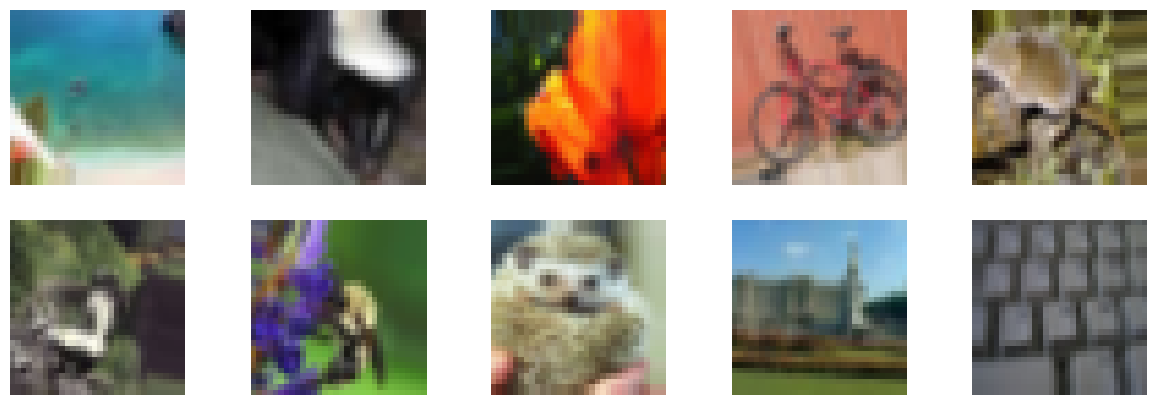

In [7]:
val_datagen = ImageDataGenerator()

batch_size = 64  # um pouco mais que o cifar 10 porque são 100 classes agora
train_generator = train_datagen.flow(X_train, y_train, batch_size=batch_size)
val_generator = val_datagen.flow(X_test, y_test, batch_size=batch_size)

aug_images, _ = next(train_generator)

# algumas imagens tranformadas
plt.figure(figsize=(15,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(aug_images[i])
    plt.axis('off')
plt.show()

In [16]:
# define a camada de entrada com 32x32 pixels e 3 canais rgb
i = Input(shape=(32,32,3))


x = Conv2D(64, (3,3), activation='relu', padding='same')(i)#64 filtros
x = BatchNormalization()(x)# batch normalization
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)# segunda camada convolucional no mesmo batch

x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)
x = Conv2D(128, (3,3), activation='relu', padding='same')(x)# segundo batch com 128 filtros
x = BatchNormalization()(x)
x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)

# transforma os mapas de caracteristicas em vetor 1d
x = Flatten()(x)
# ann com 256 neuronios
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
# dropout com taxa de 30%
x = Dropout(0.3)(x)
# camada de saida com 100 neuronios (para 100 classes) e softmax
x = Dense(100, activation='softmax')(x)

# cria o modelo definindo a entrada e saida
model = Model(i, x)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [17]:
r = model.fit(
    train_generator,
    steps_per_epoch=len(X_train)//batch_size,
    epochs=15,
    validation_data=val_generator,
    validation_steps=len(X_test)//batch_size
)

Epoch 1/15
781/781 ━━━━━━━━━━━━━━━━━━━━ 42s 45ms/step - accuracy: 0.1175 - loss: 4.0101 - val_accuracy: 0.2400 - val_loss: 3.2006
Epoch 2/15
  1/781 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.3281 - loss: 2.6770

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 905us/step - accuracy: 0.3281 - loss: 2.6770 - val_accuracy: 0.2484 - val_loss: 3.1508
Epoch 3/15
781/781 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - accuracy: 0.2894 - loss: 2.8585 - val_accuracy: 0.3490 - val_loss: 2.5321
Epoch 4/15
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 912us/step - accuracy: 0.2500 - loss: 2.9439 - val_accuracy: 0.3435 - val_loss: 2.5540
Epoch 5/15
781/781 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.3779 - loss: 2.3967 - val_accuracy: 0.4472 - val_loss: 2.1179
Epoch 6/15
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 920us/step - accuracy: 0.3438 - loss: 2.5516 - val_accuracy: 0.4448 - val_loss: 2.1301
Epoch 7/15
781/781 ━━━━━━━━━━━━━━━━━━━━ 41s 40ms/step - accuracy: 0.4323 - loss: 2.1426 - val_accuracy: 0.4598 - val_loss: 2.0728
Epoch 8/15
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 896us/step - accuracy: 0.3906 - loss: 2.4252 - val_accuracy: 0.4574 - val_loss: 2.0896
Epoch 9/15
781/781 ━━━━━━━━━━━━━━━━━━━━ 31s 39ms/step - accuracy: 0.4736 - loss: 1.9599 - val_accurac

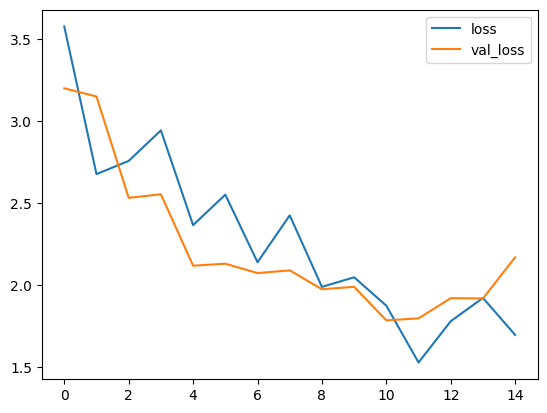

In [18]:
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

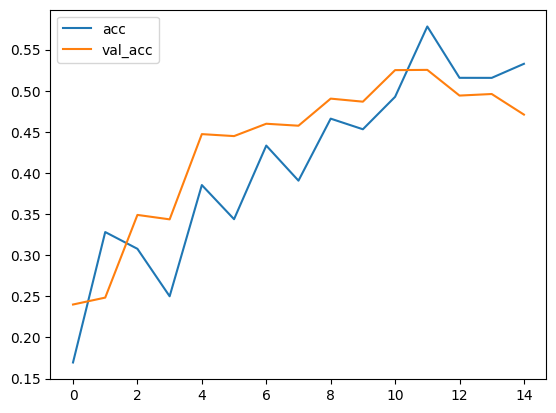

In [19]:
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


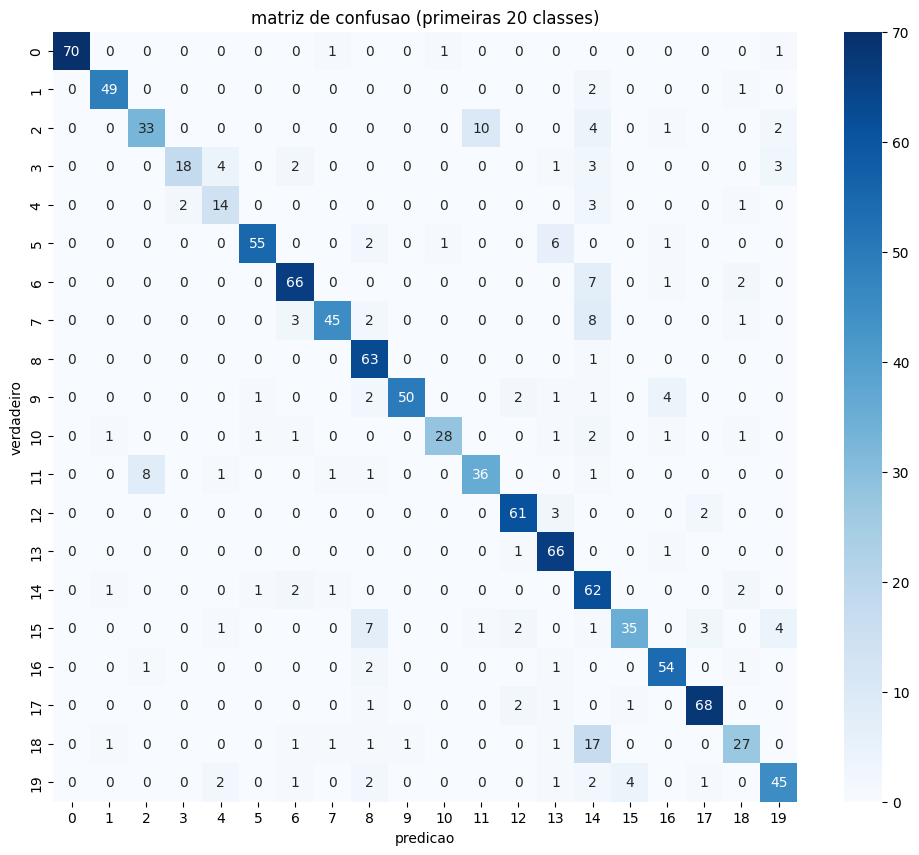

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

confusion_mtx = confusion_matrix(y_true, y_pred_classes)

# matriz de confusao - 20 classes
plt.figure(figsize=(12,10))
sns.heatmap(confusion_mtx[:20,:20], annot=True, fmt='d', cmap='Blues')
plt.xlabel('predicao')
plt.ylabel('verdadeiro')
plt.title('matriz de confusao (primeiras 20 classes)')
plt.show()
